# Análise de Relevância das Provas Genéticas na Precificação do Sêmen Bovino
**TCC - Ciência de Dados**

**Fontes de dados:**
- PMGZ (`Avaliacao_Corte2026.xls`) — análise principal: 116 touros, 15 DEPs
- ANCP (`ANCP.csv`) — análise suplementar: ~23 touros, 6 DEPs

**Métodos:** Correlação de Spearman, Random Forest, LASSO, Regressão OLS

## 1. Instalação de dependências

In [1]:
!pip install -q xlrd statsmodels

## 2. Upload dos arquivos

Faça upload dos três arquivos necessários:
- `dataset_touros_ajustado.csv`
- `Avaliacao_Corte2026.xls`
- `ANCP.csv`

In [2]:
from google.colab import files
uploaded = files.upload()
print('Arquivos enviados:', list(uploaded.keys()))

Saving ANCP.csv to ANCP (1).csv
Saving Avaliacao_Corte2026.xls to Avaliacao_Corte2026 (1).xls
Saving dataset_touros_ajustado.csv to dataset_touros_ajustado (1).csv
Arquivos enviados: ['ANCP (1).csv', 'Avaliacao_Corte2026 (1).xls', 'dataset_touros_ajustado (1).csv']


## 3. Imports e utilitários

In [3]:
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import statsmodels.api as sm

warnings.filterwarnings('ignore')
%matplotlib inline

def normaliza(s):
    if pd.isna(s):
        return ''
    return re.sub(r'\s+', '', str(s)).upper()

def to_num(s):
    if pd.isna(s):
        return float('nan')
    return pd.to_numeric(str(s).replace(',', '.'), errors='coerce')

print('Imports OK')

Imports OK


## 4. Pipeline de análise

In [4]:
def rodar_analise(df, dep_cols, nome_dataset, prefixo):
    print(f"\n{'=' * 60}")
    print(f"ANALISE: {nome_dataset}")
    print(f"{'=' * 60}")
    print(f"Touros: {len(df)}  |  DEPs: {len(dep_cols)}")
    print(f"Preco mediano -- min={df['preco_mediano'].min():.2f}  "
          f"max={df['preco_mediano'].max():.2f}  "
          f"mediana={df['preco_mediano'].median():.2f}")

    X = df[dep_cols].copy()
    y = df['preco_mediano'].copy()

    # EDA: distribuicao do preco
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(y, bins=20, edgecolor='black', color='steelblue')
    axes[0].set_title(f'Distribuicao do Preco Mediano ({nome_dataset})')
    axes[0].set_xlabel('Preco Ajustado (R$)')
    axes[0].set_ylabel('Frequencia')
    axes[1].boxplot(y)
    axes[1].set_title('Boxplot do Preco Mediano')
    axes[1].set_ylabel('Preco Ajustado (R$)')
    plt.tight_layout()
    plt.savefig(f'{prefixo}_01_distribuicao_preco.png', dpi=150)
    plt.show()

    # Correlacao de Spearman
    corr = X.corrwith(y, method='spearman').sort_values(key=abs, ascending=False)
    print('\nTop correlacoes (Spearman) com preco:')
    print(corr.to_string())

    top_n_hm = min(15, len(dep_cols))
    top_feats = corr.head(top_n_hm).index.tolist()
    corr_matrix = df[top_feats + ['preco_mediano']].corr(method='spearman')
    plt.figure(figsize=(max(10, top_n_hm), max(8, top_n_hm - 1)))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5)
    plt.title(f'Correlacao de Spearman -- {nome_dataset}')
    plt.tight_layout()
    plt.savefig(f'{prefixo}_02_heatmap_correlacao.png', dpi=150)
    plt.show()

    colors_bar = ['#d73027' if v > 0 else '#4575b4' for v in corr.head(top_n_hm).values]
    plt.figure(figsize=(10, 6))
    corr.head(top_n_hm).plot(kind='bar', color=colors_bar, edgecolor='black')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.title(f'Correlacao de Spearman com Preco -- {nome_dataset}')
    plt.ylabel('Correlacao de Spearman')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'{prefixo}_03_barplot_correlacao.png', dpi=150)
    plt.show()

    # Random Forest
    rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
    rf.fit(X, y)
    importances = pd.Series(rf.feature_importances_, index=dep_cols).sort_values(ascending=False)

    cv_r2 = cross_val_score(rf, X, y, cv=min(5, len(df) // 5), scoring='r2')
    print(f'\nRandom Forest R2 (cross-val): {cv_r2.mean():.3f} +/- {cv_r2.std():.3f}')
    print('Top importancias:')
    print(importances.head(top_n_hm).to_string())

    importances.head(top_n_hm).sort_values().plot(
        kind='barh', color='steelblue', edgecolor='black', figsize=(10, 6))
    plt.title(f'Random Forest -- Importancia das DEPs ({nome_dataset})')
    plt.xlabel('Importancia')
    plt.tight_layout()
    plt.savefig(f'{prefixo}_04_rf_feature_importance.png', dpi=150)
    plt.show()

    # LASSO
    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X)
    lasso = LassoCV(cv=min(5, len(df) // 5), random_state=42, max_iter=10000)
    lasso.fit(X_sc, y)
    coef_lasso = pd.Series(lasso.coef_, index=dep_cols)
    selecionadas = coef_lasso[coef_lasso != 0].sort_values(key=abs, ascending=False)
    print(f'\nLASSO alpha otimo: {lasso.alpha_:.4f}')
    print(f'Variaveis selecionadas: {len(selecionadas)} de {len(dep_cols)}')
    print(selecionadas.to_string())

    if len(selecionadas) > 0:
        colors_lasso = ['#d73027' if v > 0 else '#4575b4' for v in selecionadas.sort_values().values]
        plt.figure(figsize=(10, max(4, len(selecionadas) * 0.5 + 1)))
        selecionadas.sort_values().plot(kind='barh', color=colors_lasso, edgecolor='black')
        plt.axvline(0, color='black', linewidth=0.8)
        plt.title(f'LASSO -- Coeficientes Padronizados ({nome_dataset})')
        plt.xlabel('Coeficiente Padronizado')
        plt.tight_layout()
        plt.savefig(f'{prefixo}_05_lasso_coeficientes.png', dpi=150)
        plt.show()

    # OLS com features LASSO
    feats_ols = selecionadas.index.tolist() if len(selecionadas) > 0 \
        else corr.head(min(5, len(dep_cols))).index.tolist()

    X_ols = sm.add_constant(df[feats_ols])
    modelo = sm.OLS(y, X_ols).fit()
    print(f'\nRegressao OLS (R2={modelo.rsquared:.3f}, R2-adj={modelo.rsquared_adj:.3f}):')
    print(modelo.summary())

    coefs = modelo.params[1:]
    ic_lo = modelo.conf_int()[0][1:]
    ic_hi = modelo.conf_int()[1][1:]
    plt.figure(figsize=(10, max(4, len(coefs) * 0.5 + 1)))
    plt.errorbar(coefs.values, range(len(coefs)),
                 xerr=[coefs.values - ic_lo.values, ic_hi.values - coefs.values],
                 fmt='o', color='steelblue', ecolor='gray', capsize=4)
    plt.axvline(0, color='red', linestyle='--', linewidth=1)
    plt.yticks(range(len(coefs)), coefs.index)
    plt.title(f'OLS -- Coeficientes com IC 95% ({nome_dataset})')
    plt.xlabel('Coeficiente')
    plt.tight_layout()
    plt.savefig(f'{prefixo}_06_ols_coeficientes.png', dpi=150)
    plt.show()

    # Tabela sintese
    sintese = pd.DataFrame({
        'Spearman': corr,
        'RF_Importancia': importances,
        'LASSO_Coef': coef_lasso,
    })
    sintese['LASSO_selecionada'] = sintese['LASSO_Coef'] != 0
    sintese = sintese.sort_values('Spearman', key=abs, ascending=False)
    sintese.to_csv(f'{prefixo}_sintese.csv', encoding='utf-8-sig')
    print(f'\nTabela sintese salva: {prefixo}_sintese.csv')

    # Painel comparativo
    top_p = min(10, len(dep_cols))
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    corr.head(top_p).sort_values().plot(
        kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].axvline(0, color='black', linewidth=0.8)
    axes[0].set_title('Correlacao Spearman')

    importances.head(top_p).sort_values().plot(
        kind='barh', ax=axes[1], color='darkorange', edgecolor='black')
    axes[1].set_title('Random Forest -- Importancia')

    if len(selecionadas) > 0:
        selecionadas.head(top_p).sort_values().plot(
            kind='barh', ax=axes[2], color='seagreen', edgecolor='black')
        axes[2].axvline(0, color='black', linewidth=0.8)
    else:
        axes[2].text(0.5, 0.5, 'Nenhuma variavel\nselecionada', ha='center', va='center')
    axes[2].set_title('LASSO -- Coeficientes Padronizados')

    fig.suptitle(f'Relevancia das DEPs para o Preco do Semen -- {nome_dataset}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{prefixo}_07_painel_comparativo.png', dpi=150)
    plt.show()

    print(f"\nFiguras salvas com prefixo '{prefixo}_'")
    return {
        'n_touros': len(df),
        'n_deps': len(dep_cols),
        'r2_ols': modelo.rsquared,
        'r2_adj_ols': modelo.rsquared_adj,
        'r2_rf_cv': cv_r2.mean(),
        'deps_lasso': selecionadas.index.tolist(),
        'corr': corr,
        'importances': importances,
        'coef_lasso': coef_lasso,
    }

print('Pipeline definido OK')

Pipeline definido OK


## 5. Carregamento dos preços

In [5]:
print('=' * 60)
print('CARREGANDO PRECOS')
print('=' * 60)

df_preco = pd.read_csv('dataset_touros_ajustado.csv', sep=';', encoding='utf-8-sig')
df_preco['_reg_norm']   = df_preco['registro'].apply(normaliza)
df_preco['_touro_norm'] = df_preco['touro'].apply(normaliza)
df_preco['preco_num']   = df_preco['preço_ajustado'].apply(to_num)
df_preco = df_preco[df_preco['preco_num'] > 0]

print(f'Linhas de preco validas: {len(df_preco)}')

def construir_dataset(preco_df, dep_df, key_preco, key_dep, dep_cols):
    preco_agg = (
        preco_df.groupby(key_preco)['preco_num'].median().reset_index()
        .rename(columns={key_preco: '_key', 'preco_num': 'preco_mediano'})
    )
    dep_df = dep_df.rename(columns={key_dep: '_key'})
    df = preco_agg.merge(dep_df[['_key'] + dep_cols], on='_key', how='inner')
    df = df.dropna(subset=['preco_mediano'])
    return df

CARREGANDO PRECOS
Linhas de preco validas: 34739


## 6. Dataset PMGZ — análise principal


CARREGANDO PMGZ
Touros no PMGZ: 2187
Matches por codigo: 116
Matches por nome:   2
Dataset PMGZ final: 118 touros x 15 DEPs

ANALISE: PMGZ
Touros: 118  |  DEPs: 15
Preco mediano -- min=1.55  max=64.34  mediana=31.41


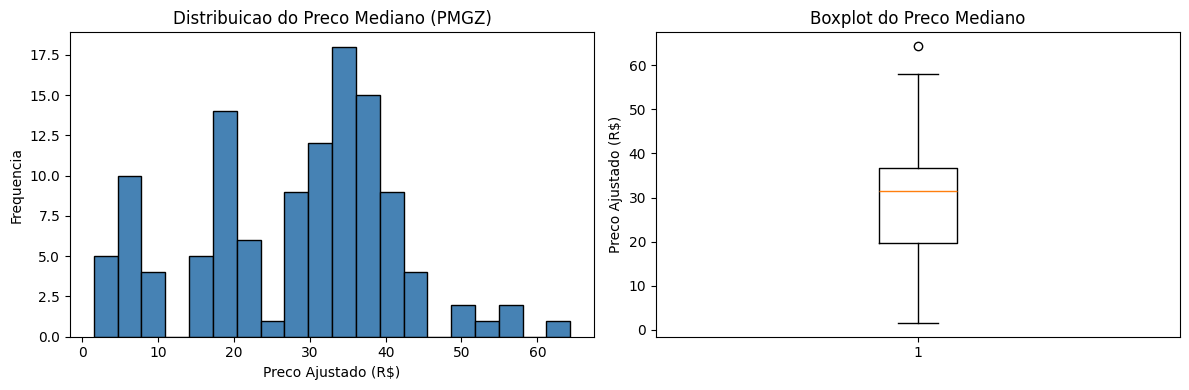


Top correlacoes (Spearman) com preco:
PM_DEP      -0.183491
PD_DEP      -0.179108
MAR_DEP      0.172418
PA_DEP      -0.145473
PS_DEP      -0.133347
PSN_DEP     -0.123928
PN_DEP      -0.119733
M_DEP       -0.115600
IPP_DEP     -0.058654
ACAB_DEP     0.041110
P_DEP       -0.027753
PE365_DEP   -0.026759
E_DEP       -0.026173
AOL_DEP     -0.024827
STAY_DEP     0.009020


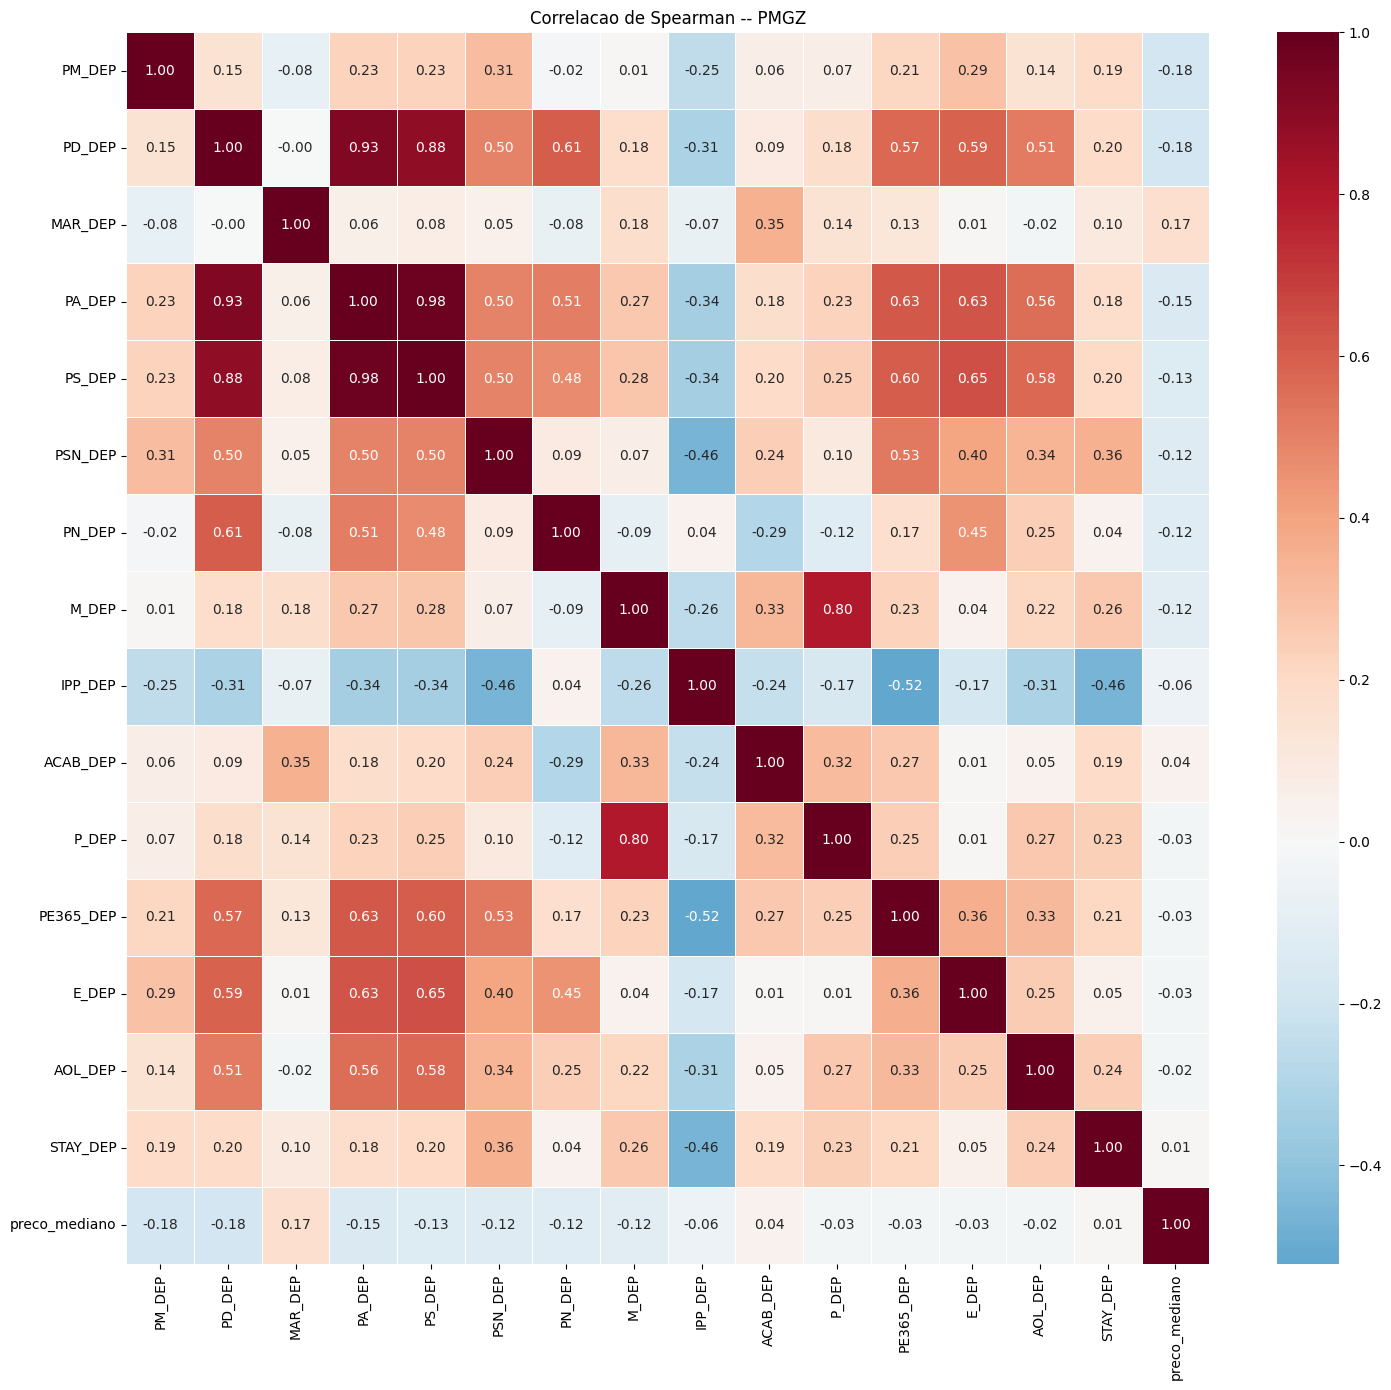

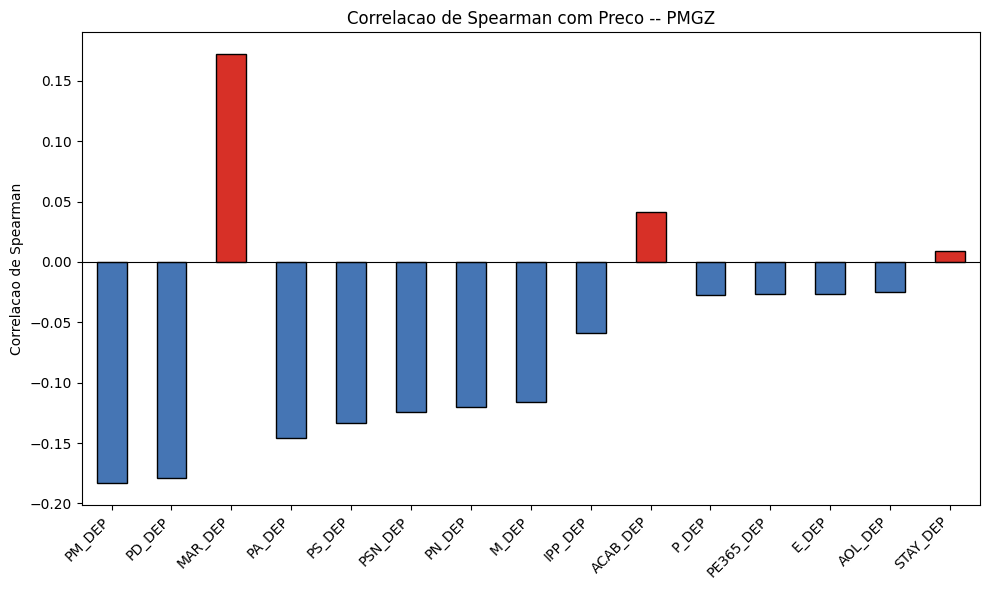


Random Forest R2 (cross-val): -0.363 +/- 0.279
Top importancias:
MAR_DEP      0.102234
PM_DEP       0.100993
PSN_DEP      0.088439
ACAB_DEP     0.080624
AOL_DEP      0.076363
E_DEP        0.070194
M_DEP        0.066636
IPP_DEP      0.065694
P_DEP        0.060336
PN_DEP       0.055518
PE365_DEP    0.051883
PD_DEP       0.051662
PA_DEP       0.044398
STAY_DEP     0.044300
PS_DEP       0.040725


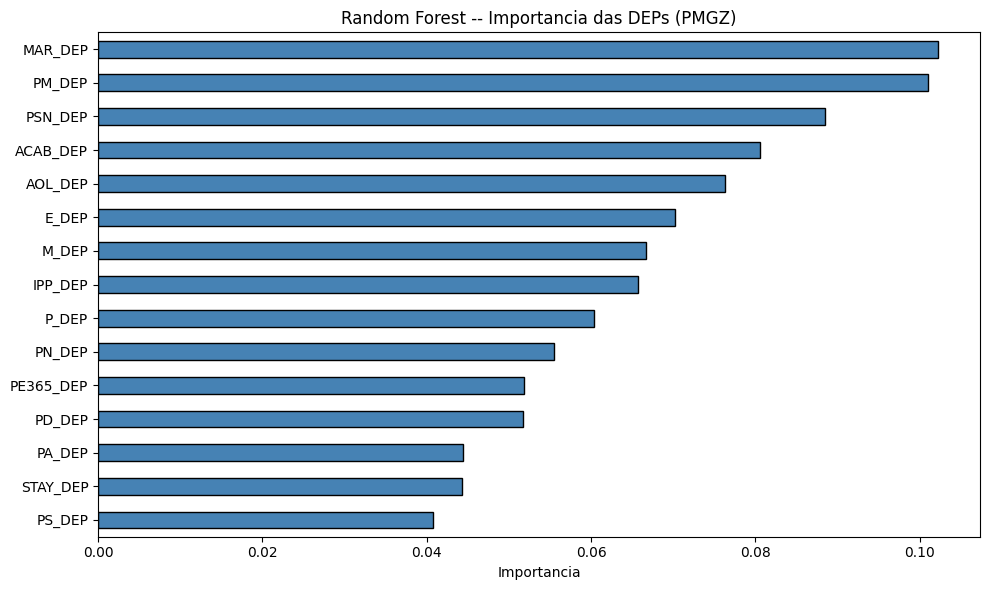


LASSO alpha otimo: 1.8668
Variaveis selecionadas: 3 de 15
PD_DEP    -0.969921
PM_DEP    -0.922716
MAR_DEP    0.257809


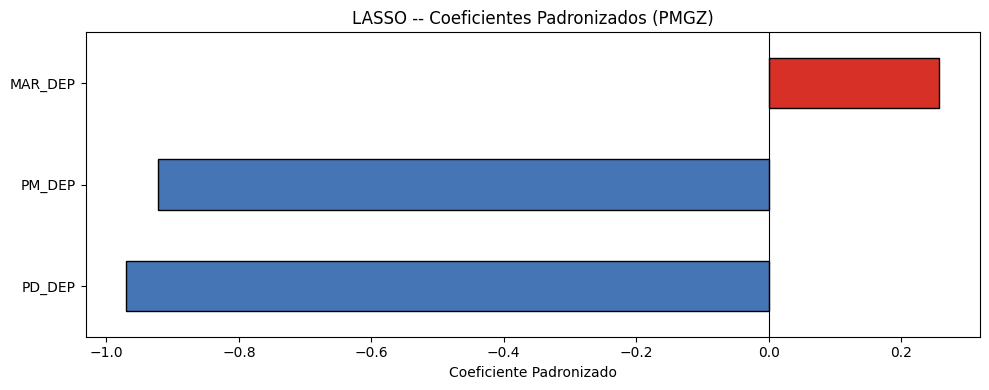


Regressao OLS (R2=0.110, R2-adj=0.086):
                            OLS Regression Results                            
Dep. Variable:          preco_mediano   R-squared:                       0.110
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     4.690
Date:                Wed, 20 May 2026   Prob (F-statistic):            0.00399
Time:                        15:45:42   Log-Likelihood:                -465.78
No. Observations:                 118   AIC:                             939.6
Df Residuals:                     114   BIC:                             950.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

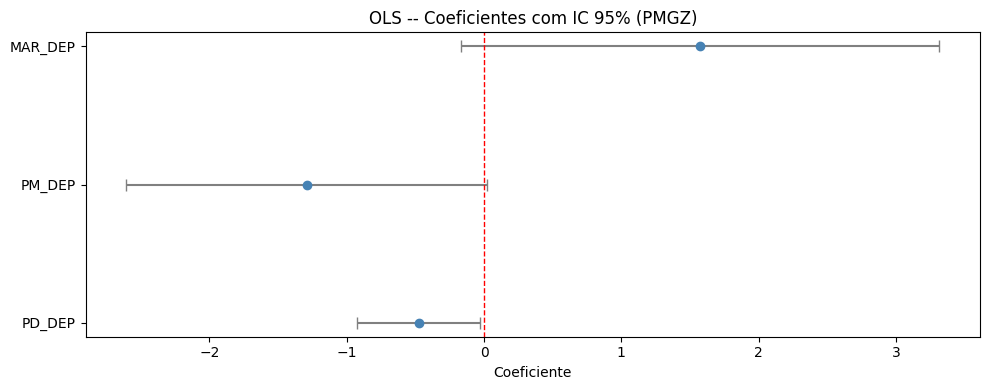


Tabela sintese salva: pmgz_sintese.csv


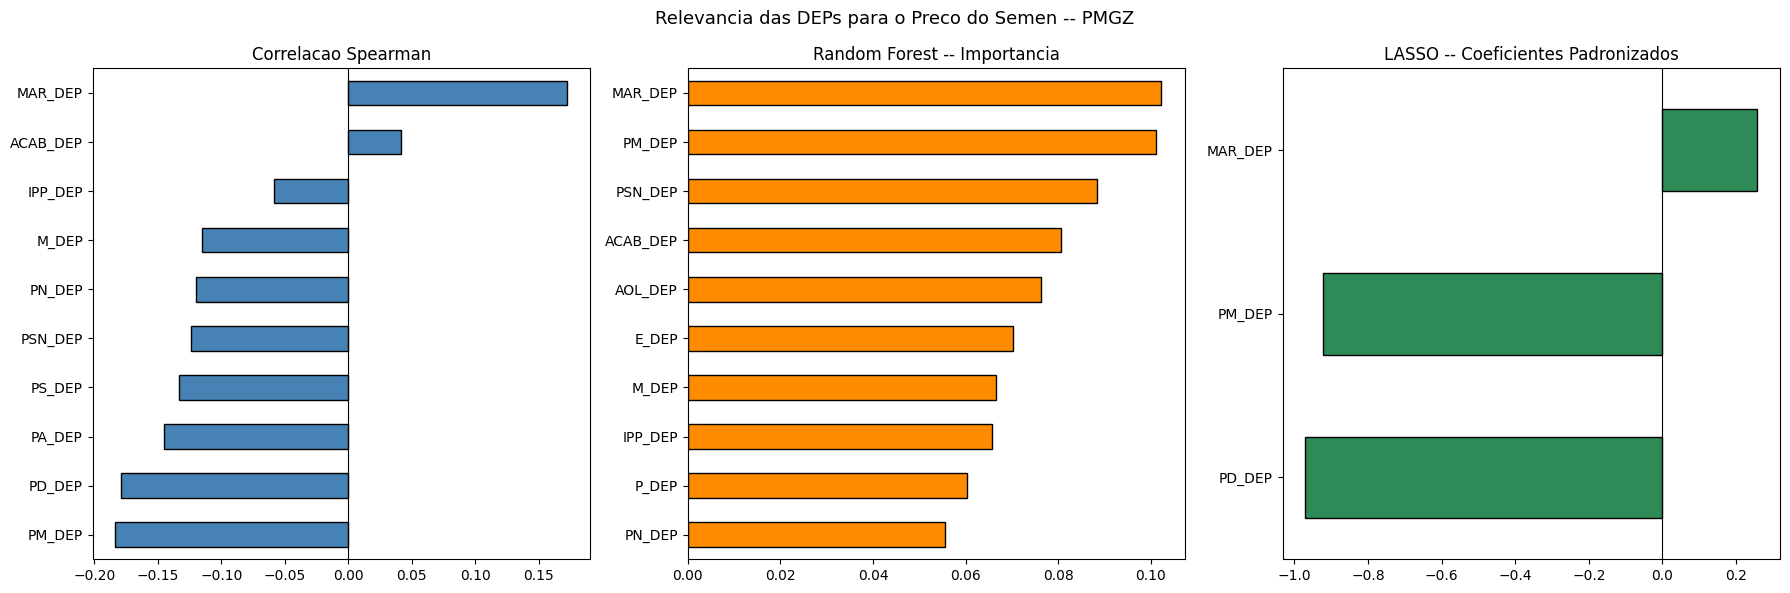


Figuras salvas com prefixo 'pmgz_'


In [6]:
print('\n' + '=' * 60)
print('CARREGANDO PMGZ')
print('=' * 60)

DEP_MAP_PMGZ = {
    27: 'PN_DEP',    # Peso ao nascimento
    31: 'PD_DEP',    # Peso a desmama
    35: 'PA_DEP',    # Peso ao ano
    39: 'PS_DEP',    # Peso ao sobreano
    43: 'PM_DEP',    # Peso materno
    47: 'IPP_DEP',   # Idade primeiro parto
    51: 'STAY_DEP',  # Stayability
    55: 'PE365_DEP', # Perimetro escrotal 365d
    59: 'PSN_DEP',   # Precocidade sexual natural
    63: 'AOL_DEP',   # Area olho de lombo
    67: 'ACAB_DEP',  # Acabamento de carcaca
    71: 'MAR_DEP',   # Marmoreio
    75: 'E_DEP',     # Estrutura corporal
    79: 'P_DEP',     # Precocidade
    83: 'M_DEP',     # Musculosidade
}
DEP_COLS_PMGZ = list(DEP_MAP_PMGZ.values())

raw_pmgz = pd.read_excel('Avaliacao_Corte2026.xls', engine='xlrd', header=None, skiprows=7)
raw_pmgz['_cod_norm'] = (
    raw_pmgz[1].astype(str).str.strip() +
    raw_pmgz[2].astype(str).str.strip()
).str.upper()
raw_pmgz['_nome_norm'] = raw_pmgz[0].apply(normaliza)

for col_idx, name in DEP_MAP_PMGZ.items():
    raw_pmgz[name] = raw_pmgz[col_idx].apply(to_num)

print(f'Touros no PMGZ: {len(raw_pmgz)}')

# Join por registro
pmgz_match_reg = set(df_preco['_reg_norm']) & set(raw_pmgz['_cod_norm']) - {''}
df_preco_reg = df_preco[df_preco['_reg_norm'].isin(pmgz_match_reg)].copy()
df_pmgz_reg  = raw_pmgz[raw_pmgz['_cod_norm'].isin(pmgz_match_reg)].copy()
df_pmgz_a = construir_dataset(df_preco_reg, df_pmgz_reg, '_reg_norm', '_cod_norm', DEP_COLS_PMGZ)

# Fallback por nome
ja_matched = set(df_pmgz_a['_key'])
df_preco_resto = df_preco[~df_preco['_reg_norm'].isin(ja_matched)]
pmgz_match_nome = set(df_preco_resto['_touro_norm']) & set(raw_pmgz['_nome_norm']) - {''}
df_preco_nome = df_preco_resto[df_preco_resto['_touro_norm'].isin(pmgz_match_nome)].copy()
df_pmgz_nome  = raw_pmgz[raw_pmgz['_nome_norm'].isin(pmgz_match_nome)].copy()
df_pmgz_b = construir_dataset(df_preco_nome, df_pmgz_nome, '_touro_norm', '_nome_norm', DEP_COLS_PMGZ)

df_pmgz = pd.concat([df_pmgz_a, df_pmgz_b], ignore_index=True).drop_duplicates('_key')
df_pmgz = df_pmgz[df_pmgz['preco_mediano'] > 0]

# Remover DEPs com >50% nulos e imputar mediana
thresh = len(df_pmgz) * 0.5
df_pmgz_clean = df_pmgz.dropna(axis=1, thresh=thresh)
dep_pmgz_usadas = [c for c in DEP_COLS_PMGZ if c in df_pmgz_clean.columns]
for col in dep_pmgz_usadas:
    df_pmgz_clean[col] = df_pmgz_clean[col].fillna(df_pmgz_clean[col].median())

print(f'Matches por codigo: {len(pmgz_match_reg)}')
print(f'Matches por nome:   {len(pmgz_match_nome)}')
print(f'Dataset PMGZ final: {len(df_pmgz_clean)} touros x {len(dep_pmgz_usadas)} DEPs')

res_pmgz = rodar_analise(df_pmgz_clean, dep_pmgz_usadas, 'PMGZ', 'pmgz')

## 7. Dataset ANCP — análise suplementar


CARREGANDO ANCP
Dataset ANCP final: 23 touros x 6 DEPs

ANALISE: ANCP
Touros: 23  |  DEPs: 6
Preco mediano -- min=22.48  max=70.25  mediana=40.58


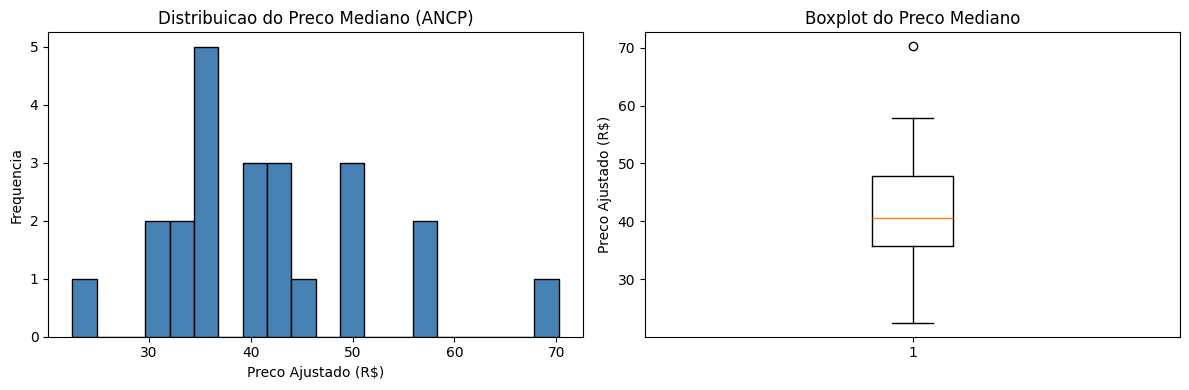


Top correlacoes (Spearman) com preco:
P450 DEP    -0.530299
AOL DEP     -0.261457
STAY DEP    -0.241315
3P DEP      -0.178418
MP120 DEP   -0.143336
PE365 DEP    0.012742


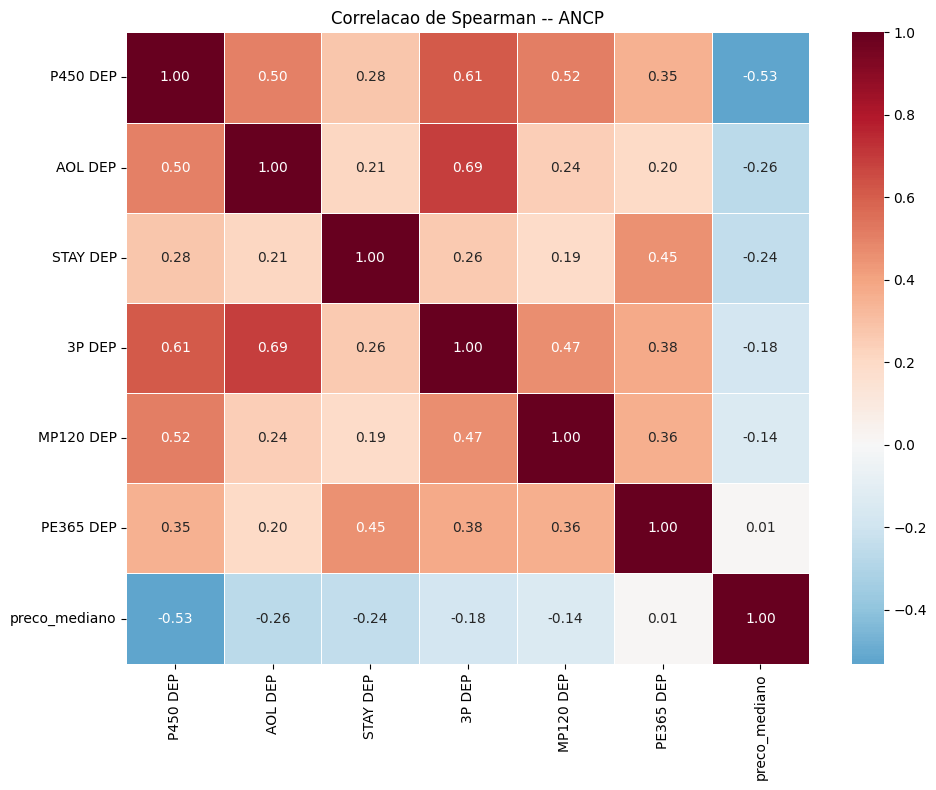

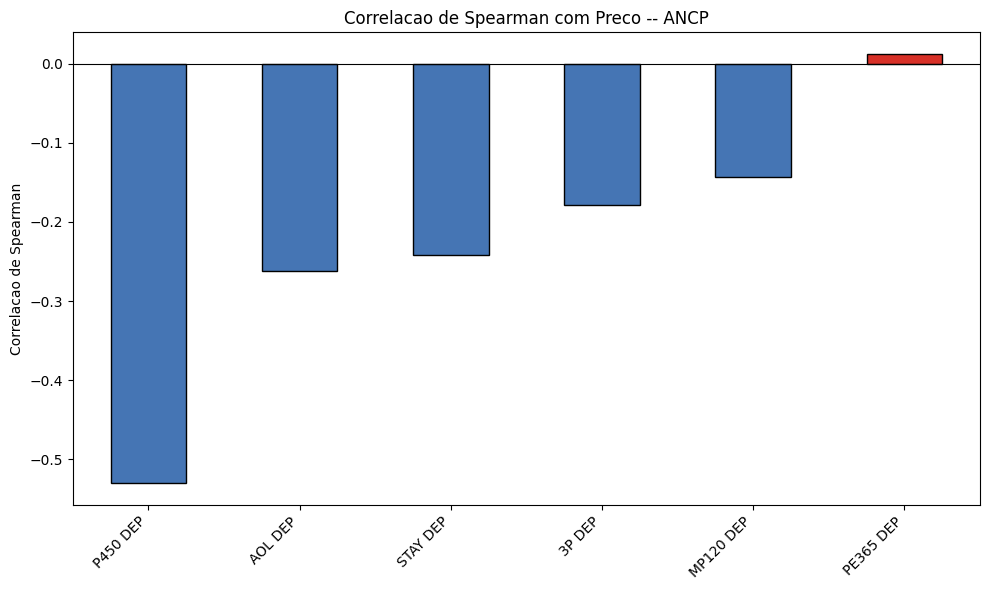


Random Forest R2 (cross-val): 0.070 +/- 0.539
Top importancias:
P450 DEP     0.538638
3P DEP       0.208505
MP120 DEP    0.075513
STAY DEP     0.062199
PE365 DEP    0.060297
AOL DEP      0.054849


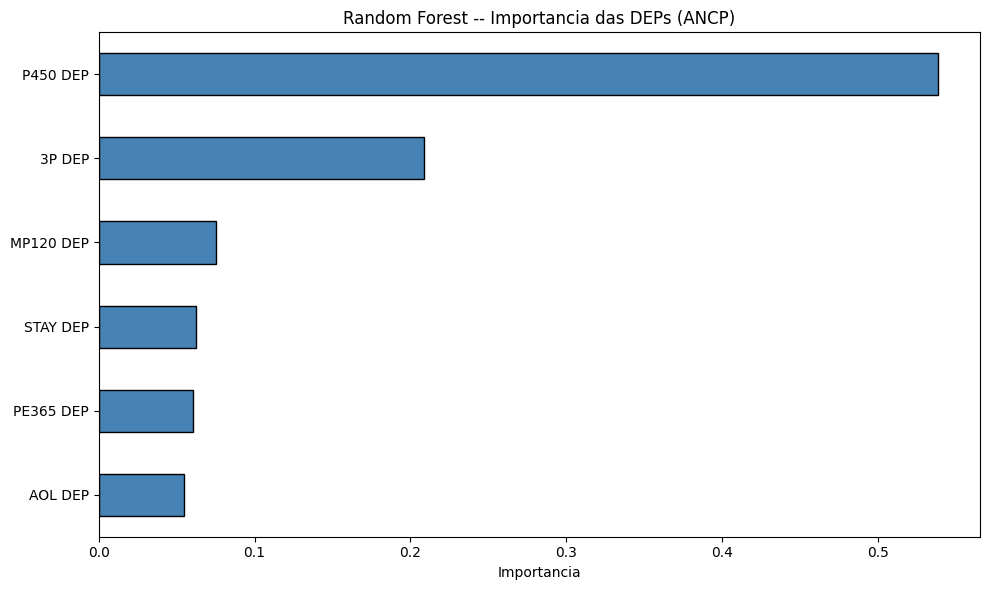


LASSO alpha otimo: 1.3208
Variaveis selecionadas: 2 de 6
P450 DEP    -5.901983
PE365 DEP    1.283670


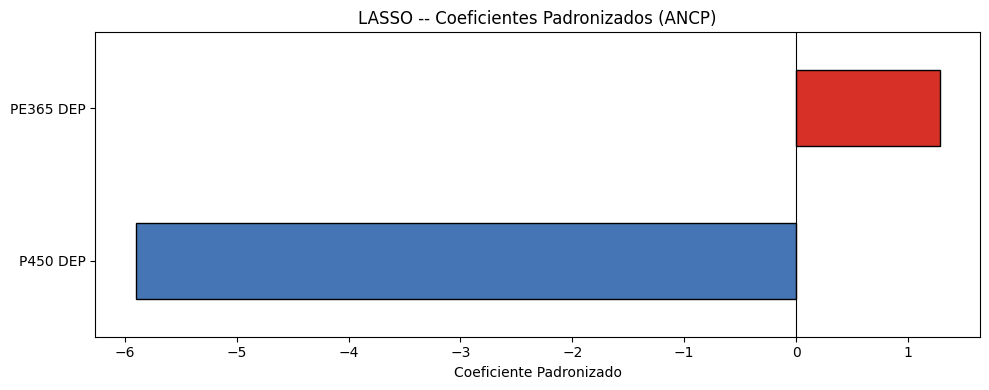


Regressao OLS (R2=0.527, R2-adj=0.480):
                            OLS Regression Results                            
Dep. Variable:          preco_mediano   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.480
Method:                 Least Squares   F-statistic:                     11.16
Date:                Wed, 20 May 2026   Prob (F-statistic):           0.000556
Time:                        15:45:50   Log-Likelihood:                -77.959
No. Observations:                  23   AIC:                             161.9
Df Residuals:                      20   BIC:                             165.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

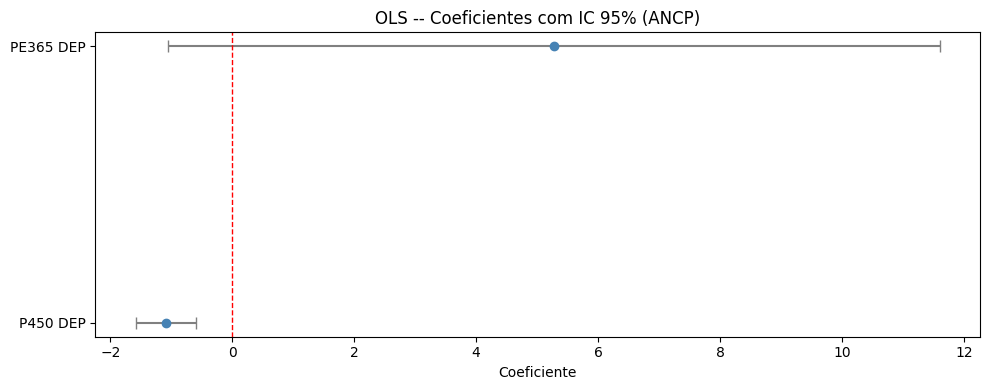


Tabela sintese salva: ancp_sintese.csv


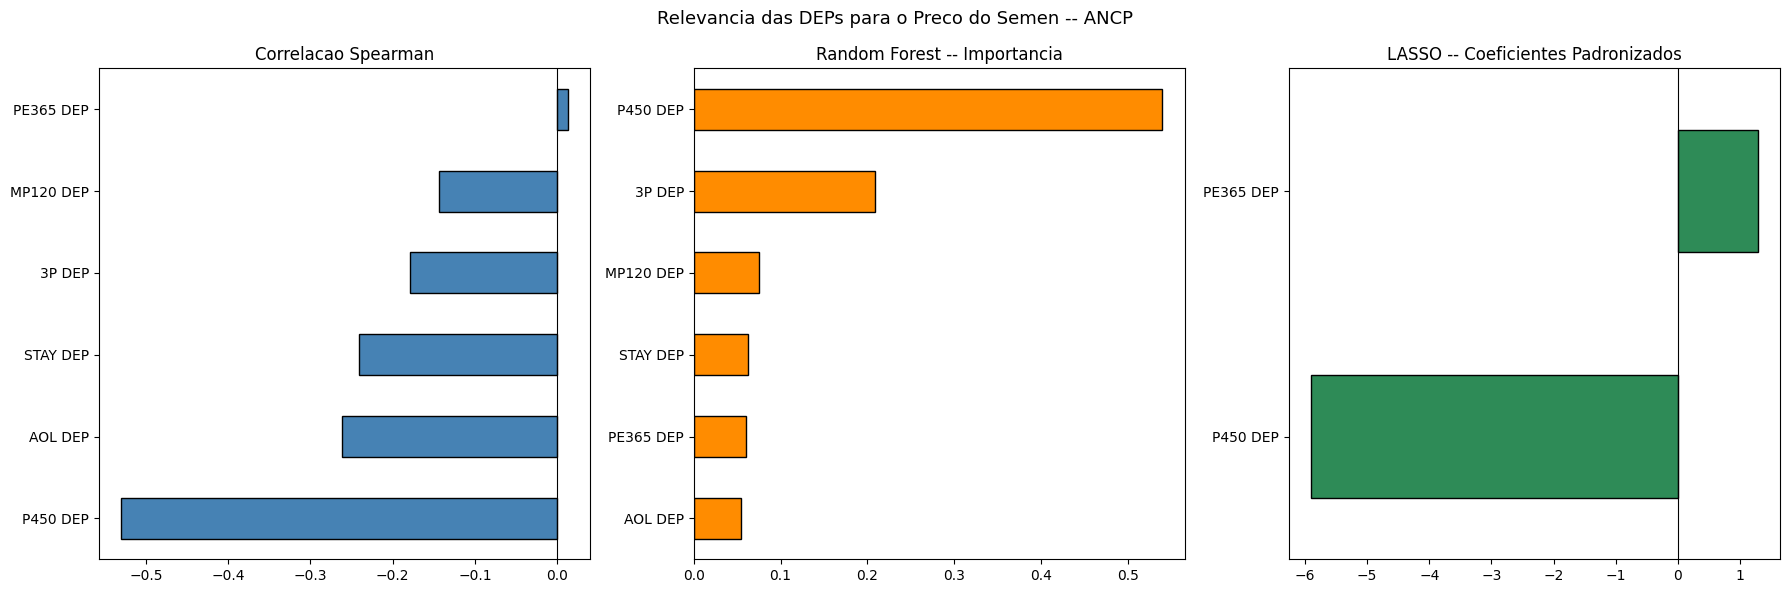


Figuras salvas com prefixo 'ancp_'


In [7]:
print('\n' + '=' * 60)
print('CARREGANDO ANCP')
print('=' * 60)

df_ancp = pd.read_csv('ANCP.csv', sep=',', encoding='utf-8-sig')
df_ancp['_rg_norm']   = df_ancp['RG'].apply(normaliza)
df_ancp['_nome_norm'] = df_ancp['NOME'].apply(normaliza)
DEP_COLS_ANCP = [c for c in df_ancp.columns if c.endswith(' DEP')]

match_ancp_reg  = set(df_preco['_reg_norm'])   & set(df_ancp['_rg_norm'])   - {''}
match_ancp_nome = set(df_preco['_touro_norm']) & set(df_ancp['_nome_norm']) - {''}

df_preco_areg = df_preco[df_preco['_reg_norm'].isin(match_ancp_reg)].copy()
df_ancp_reg   = df_ancp[df_ancp['_rg_norm'].isin(match_ancp_reg)].copy()
df_ancp_a = construir_dataset(df_preco_areg, df_ancp_reg, '_reg_norm', '_rg_norm', DEP_COLS_ANCP)

ja_ancp = set(df_ancp_a['_key'])
df_preco_anome = df_preco[~df_preco['_reg_norm'].isin(ja_ancp) &
                           df_preco['_touro_norm'].isin(match_ancp_nome)].copy()
df_ancp_nome   = df_ancp[df_ancp['_nome_norm'].isin(match_ancp_nome)].copy()
df_ancp_b = construir_dataset(df_preco_anome, df_ancp_nome, '_touro_norm', '_nome_norm', DEP_COLS_ANCP)

df_ancp_all = pd.concat([df_ancp_a, df_ancp_b], ignore_index=True).drop_duplicates('_key')
df_ancp_all = df_ancp_all[df_ancp_all['preco_mediano'] > 0]

for col in DEP_COLS_ANCP:
    df_ancp_all[col] = pd.to_numeric(df_ancp_all[col], errors='coerce')
thresh_a = len(df_ancp_all) * 0.5
df_ancp_clean = df_ancp_all.dropna(axis=1, thresh=thresh_a)
dep_ancp_usadas = [c for c in DEP_COLS_ANCP if c in df_ancp_clean.columns]
for col in dep_ancp_usadas:
    df_ancp_clean[col] = df_ancp_clean[col].fillna(df_ancp_clean[col].median())

print(f'Dataset ANCP final: {len(df_ancp_clean)} touros x {len(dep_ancp_usadas)} DEPs')

if len(df_ancp_clean) >= 10 and len(dep_ancp_usadas) >= 2:
    res_ancp = rodar_analise(df_ancp_clean, dep_ancp_usadas, 'ANCP', 'ancp')
else:
    print('ANCP: amostra insuficiente para analise completa.')
    res_ancp = None

## 8. Resumo comparativo final

In [8]:
print('\n' + '=' * 60)
print('RESUMO FINAL')
print('=' * 60)

print(f"\n{'Dataset':<8} {'Touros':>8} {'DEPs':>6} {'R2 OLS':>8} {'R2-adj':>8} {'R2 RF-CV':>10}")
print('-' * 52)
print(f"{'PMGZ':<8} {res_pmgz['n_touros']:>8} {res_pmgz['n_deps']:>6} "
      f"{res_pmgz['r2_ols']:>8.3f} {res_pmgz['r2_adj_ols']:>8.3f} "
      f"{res_pmgz['r2_rf_cv']:>10.3f}")
if res_ancp:
    print(f"{'ANCP':<8} {res_ancp['n_touros']:>8} {res_ancp['n_deps']:>6} "
          f"{res_ancp['r2_ols']:>8.3f} {res_ancp['r2_adj_ols']:>8.3f} "
          f"{res_ancp['r2_rf_cv']:>10.3f}")

print(f"\nDEPs PMGZ selecionadas pelo LASSO: {res_pmgz['deps_lasso']}")
if res_ancp:
    print(f"DEPs ANCP selecionadas pelo LASSO: {res_ancp['deps_lasso']}")


RESUMO FINAL

Dataset    Touros   DEPs   R2 OLS   R2-adj   R2 RF-CV
----------------------------------------------------
PMGZ          118     15    0.110    0.086     -0.363
ANCP           23      6    0.527    0.480      0.070

DEPs PMGZ selecionadas pelo LASSO: ['PD_DEP', 'PM_DEP', 'MAR_DEP']
DEPs ANCP selecionadas pelo LASSO: ['P450 DEP', 'PE365 DEP']


## 9. Download dos arquivos gerados

In [9]:
import os
from google.colab import files

arquivos_gerados = []
for prefix in ['pmgz', 'ancp']:
    for sufixo in ['01_distribuicao_preco', '02_heatmap_correlacao', '03_barplot_correlacao',
                   '04_rf_feature_importance', '05_lasso_coeficientes',
                   '06_ols_coeficientes', '07_painel_comparativo']:
        fname = f'{prefix}_{sufixo}.png'
        if os.path.exists(fname):
            arquivos_gerados.append(fname)
    csv_fname = f'{prefix}_sintese.csv'
    if os.path.exists(csv_fname):
        arquivos_gerados.append(csv_fname)

print(f'Arquivos gerados: {len(arquivos_gerados)}')
for f in arquivos_gerados:
    print(f'  {f}')
    files.download(f)

Arquivos gerados: 16
  pmgz_01_distribuicao_preco.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  pmgz_02_heatmap_correlacao.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ancp_sintese.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>